# nb07 — CITE protein support for reproducible RNA programs

## Scientific question
Do individual measured surface proteins covary with the same five RNA programs
reviewed in nb06, within paired CITE cells of the selected donor?

## Analysis strategy
Reuse nb04's CITE RNA, nb05's supported shortlist and nb06's selected panel.
Audit antibody labels before distinguishing **direct molecular matches** from
**exploratory phenotypic context**. No CITE cells are matched to Multiome cells.
Missing ADTs provide no evidence about protein activity. Intracellular E2F/Myc
programs may have no useful surface-panel coverage.

Copy this notebook, `src/protein_programs.py` and `src/protein_plots.py` into the
existing Drive project. Keep the shared modules used for nb04–06. Restart a reused
Colab runtime after copying modules. Run cells in order.

In [1]:
from pathlib import Path
import sys
import subprocess

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Same Drive root as nb01. No changes to the original benchmark files.
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'anndata>=0.11,<0.13'])
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics-relationship-modeling')
else:
    BASE_PATH = Path.cwd().resolve()
    if not (BASE_PATH / 'src').is_dir():
        BASE_PATH = BASE_PATH.parent

if not (BASE_PATH / 'src/single_donor_workflow.py').is_file():
    raise FileNotFoundError('Copy the updated src/, configs/ and new notebooks to the project on Drive first.')
sys.path.insert(0, str(BASE_PATH))
import pandas as pd
from IPython.display import display, Image
from configs.paths import CITE_H5AD, MULTIOME_H5AD
from src.single_donor_io import output_dirs

OUTPUT_ROOT = BASE_PATH / 'results/single_donor'
DIRS = output_dirs(OUTPUT_ROOT)
print('Colab:', IN_COLAB, '| Project:', BASE_PATH)

Mounted at /content/drive
Colab: True | Project: /content/drive/MyDrive/multiomics-relationship-modeling


In [2]:
import shutil
from src.protein_programs import run_protein

MIN_CELLS_FOR_ASSOCIATION = 50
CITE_INPUT = CITE_H5AD
# Reading HDF5 repeatedly over Drive can be slow. Copy once per notebook run.
if str(BASE_PATH).startswith('/content/drive/'):
    CITE_INPUT = Path('/content/nb07_cite_processed.h5ad')
    required = CITE_H5AD.stat().st_size
    if shutil.disk_usage('/content').free < required:
        raise RuntimeError('Insufficient Colab disk space for local CITE copy')
    print(f'Copying {required / 1e6:.0f} MB from Drive to Colab local disk...', flush=True)
    shutil.copyfile(CITE_H5AD, CITE_INPUT)
    assert CITE_INPUT.stat().st_size == required
    print('Local copy ready.', flush=True)

Copying 625 MB from Drive to Colab local disk...
Local copy ready.


## Representation and safeguards
RNA retains nb04's log1p(CP10k) values. Each module uses variable pathway genes
in the shared RNA universe, with equal cell-type weight in the reference mean and
variance. Require at least 10 genes. This score has a different gene coverage from
nb06 and must not be compared numerically across assays as an absolute effect.

ADT comes from raw `layers['counts']`, aligned by CITE cell ID and checked against
donor, site and original cell type. Exclude labelled isotype controls and zero-total
biological-ADT cells. Primary transform is explicitly **log(1+count) minus the
cell's mean log(1+count) over biological ADTs**. This relative panel transformation
is not background correction. Uncentered log1p ADT is a sensitivity comparison.

CD3, CD8, CD16/CD32, CD57, CD45RA/RO and HLA family labels are not assumed to
measure one unique gene. Consult the saved mapping audit and clone metadata.
Direct matches mean mapped genes belonging to the GMT pathway, not validation of
the whole pathway. Individual ADTs are reported without a forced aggregate score.

CD86 and HLA-DR are exploratory surface context for the three immune programs.
Their functions are described by [UniProt CD86](https://www.uniprot.org/uniprotkb/P42081/entry)
and [UniProt HLA-DRA](https://www.uniprot.org/entry/P01903); these references do not
establish a specific relationship or expected correlation direction with our RNA
scores. HLA-DR is not a direct HLA-DRA molecular match. No forced E2F/Myc proxies.

Report target-population and within-site Pearson/Spearman correlations. Residual
Pearson adjusts both measurements for log RNA/ADT count totals and site indicators;
residual Spearman is correlation of OLS residual ranks. These are sensitivity
analyses, not causal estimates. No cell-level p-values or donor inference.

In [3]:
tables, protein_manifest = run_protein(
    OUTPUT_ROOT, CITE_INPUT, min_cells=MIN_CELLS_FOR_ASSOCIATION)
PROTEIN_DIR = OUTPUT_ROOT / 'protein'
print('Donor:', protein_manifest['donor'])
display(tables['coverage'].drop(columns='rna_genes'))
display(tables['cell_qc'].groupby(['cell_type_harmonized', 'included_protein'], observed=True).size().rename('n_cells').reset_index())

[0.0 min] Checking RNA artifact: rna_concordance/shared_gene_universe.csv
[0.0 min] Checking RNA artifact: gsea/used_collection.gmt
[0.0 min] Checking RNA artifact: rna_cite/gene_programs.csv
[0.0 min] Checking RNA artifact: rna_cite/rna_log1p_cp10k.npz
[0.1 min] Checking RNA artifact: rna_cite/cells.csv
[0.1 min] Checking RNA artifact: rna_cite/genes.csv
[0.1 min] Checking RNA artifact: gsea/cite_enrichment.csv
[0.1 min] Checking RNA artifact: gsea/multiome_enrichment.csv
[0.2 min] Reading paired ADT counts
[0.2 min] ADT cells read: 1,024/29,688
[0.2 min] ADT cells read: 2,048/29,688
[0.2 min] ADT cells read: 3,072/29,688
[0.2 min] ADT cells read: 4,096/29,688
[0.2 min] ADT cells read: 5,120/29,688
[0.2 min] ADT cells read: 6,144/29,688
[0.2 min] ADT cells read: 7,168/29,688
[0.2 min] ADT cells read: 8,192/29,688
[0.2 min] ADT cells read: 9,216/29,688
[0.2 min] ADT cells read: 10,240/29,688
[0.2 min] ADT cells read: 11,264/29,688
[0.2 min] ADT cells read: 12,288/29,688
[0.2 min] ADT c

,program_id,cell_type,pathway,n_pathway_genes,n_rna_module_genes,rna_module_tested,n_direct_adts,n_direct_genes,direct_gene_coverage,protein_coverage_status
0,P01,CD14 monocytes,Inflammatory Response,200,128,True,14,14,0.070000,measured subset only
1,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,200,160,True,6,6,0.030000,measured subset only
2,P03,CD16 monocytes,Interferon Alpha Response,97,84,True,3,3,0.030928,measured subset only
3,P04,Lymphoid progenitors,E2F Targets,200,195,True,1,1,0.005000,measured subset only
4,P05,MK/E progenitors,Myc Targets V1,200,196,True,0,0,0.000000,no direct ADT coverage


,cell_type_harmonized,included_protein,n_cells
0,B cells,True,3449
1,CD14 monocytes,True,7244
2,CD16 monocytes,True,865
3,CD4 T cells,True,5619
4,CD8 T cells,True,2545
5,Erythroid populations,True,5067
6,G/M progenitors,True,517
7,HSC,True,455
8,ILC,True,151
9,Lymphoid progenitors,True,449


## Panel audit and evidence tiers
Review unresolved antigens and absent candidates before interpreting correlations.
Measured direct ADTs with constant or insufficient data remain untested, not negative.

In [4]:
with pd.option_context('display.max_rows', None, 'display.max_colwidth', 100):
    display(tables['mapping'])
    display(tables['evidence'])
display(tables['population_summary'])

,adt,gene,is_control,direct_match,mapping_status,reason
0,CD86,CD86,False,True,direct,Exact antigen/gene symbol match
1,CD274,CD274,False,False,RNA unmeasured,Existing curated CD-to-gene alias; conservative ambiguity overrides applied
2,CD270,TNFRSF14,False,True,direct,Existing curated CD-to-gene alias; conservative ambiguity overrides applied
3,CD155,PVR,False,True,direct,Existing curated CD-to-gene alias; conservative ambiguity overrides applied
4,CD112,NECTIN2,False,True,direct,Existing curated CD-to-gene alias; conservative ambiguity overrides applied
5,CD47,CD47,False,True,direct,Exact antigen/gene symbol match
6,CD48,CD48,False,True,direct,Exact antigen/gene symbol match
7,CD40,CD40,False,True,direct,Exact antigen/gene symbol match
8,CD154,CD40LG,False,True,direct,Existing curated CD-to-gene alias; conservative ambiguity overrides applied
9,CD52,CD52,False,True,direct,Exact antigen/gene symbol match


,program_id,cell_type,pathway,adt,gene,evidence_type,measured,rationale,reference
0,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,direct molecular match,True,Unique mapped antigen gene is in pathway,src/analysis/cd_gene_mapping.py + mapping audit
1,P01,CD14 monocytes,Inflammatory Response,CD48,CD48,direct molecular match,True,Unique mapped antigen gene is in pathway,src/analysis/cd_gene_mapping.py + mapping audit
2,P01,CD14 monocytes,Inflammatory Response,CD40,CD40,direct molecular match,True,Unique mapped antigen gene is in pathway,src/analysis/cd_gene_mapping.py + mapping audit
3,P01,CD14 monocytes,Inflammatory Response,CD14,CD14,direct molecular match,True,Unique mapped antigen gene is in pathway,src/analysis/cd_gene_mapping.py + mapping audit
4,P01,CD14 monocytes,Inflammatory Response,CD69,CD69,direct molecular match,True,Unique mapped antigen gene is in pathway,src/analysis/cd_gene_mapping.py + mapping audit
5,P01,CD14 monocytes,Inflammatory Response,CD62L,SELL,direct molecular match,True,Unique mapped antigen gene is in pathway,src/analysis/cd_gene_mapping.py + mapping audit
6,P01,CD14 monocytes,Inflammatory Response,CD42b,GP1BA,direct molecular match,True,Unique mapped antigen gene is in pathway,src/analysis/cd_gene_mapping.py + mapping audit
7,P01,CD14 monocytes,Inflammatory Response,CD54,ICAM1,direct molecular match,True,Unique mapped antigen gene is in pathway,src/analysis/cd_gene_mapping.py + mapping audit
8,P01,CD14 monocytes,Inflammatory Response,CD122,IL2RB,direct molecular match,True,Unique mapped antigen gene is in pathway,src/analysis/cd_gene_mapping.py + mapping audit
9,P01,CD14 monocytes,Inflammatory Response,CD137,TNFRSF9,direct molecular match,True,Unique mapped antigen gene is in pathway,src/analysis/cd_gene_mapping.py + mapping audit


,program_id,cell_type,pathway,adt,gene,evidence_type,n_cells,rna_module_mean,adt_mean_centered_log,adt_mean_z,adt_nonzero_fraction,interpretation
0,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,direct molecular match,7244,0.282337,-0.442717,0.421134,0.932496,measured subset/context only; no whole-pathway...
1,P01,CD14 monocytes,Inflammatory Response,CD48,CD48,direct molecular match,7244,0.282337,1.663090,0.438281,1.000000,measured subset/context only; no whole-pathway...
2,P01,CD14 monocytes,Inflammatory Response,CD40,CD40,direct molecular match,7244,0.282337,-0.425091,-0.448036,0.915378,measured subset/context only; no whole-pathway...
3,P01,CD14 monocytes,Inflammatory Response,CD14,CD14,direct molecular match,7244,0.282337,0.500845,1.759471,0.976946,measured subset/context only; no whole-pathway...
4,P01,CD14 monocytes,Inflammatory Response,CD69,CD69,direct molecular match,7244,0.282337,-1.143967,-0.225979,0.744202,measured subset/context only; no whole-pathway...
5,P01,CD14 monocytes,Inflammatory Response,CD62L,SELL,direct molecular match,7244,0.282337,-0.100453,0.549644,0.925318,measured subset/context only; no whole-pathway...
6,P01,CD14 monocytes,Inflammatory Response,CD42b,GP1BA,direct molecular match,7244,0.282337,-0.935441,0.100094,0.817090,measured subset/context only; no whole-pathway...
7,P01,CD14 monocytes,Inflammatory Response,CD54,ICAM1,direct molecular match,7244,0.282337,0.510104,0.359596,0.985505,measured subset/context only; no whole-pathway...
8,P01,CD14 monocytes,Inflammatory Response,CD122,IL2RB,direct molecular match,7244,0.282337,-0.640595,-0.618836,0.866510,measured subset/context only; no whole-pathway...
9,P01,CD14 monocytes,Inflammatory Response,CD137,TNFRSF9,direct molecular match,7244,0.282337,0.052625,-0.411332,0.950718,measured subset/context only; no whole-pathway...


## Paired within-population relationships
Compare module–ADT associations to the direct same-gene RNA–ADT associations.
Inspect site heterogeneity, depth adjustment and normalization sensitivity. Small
site groups remain visible but untested. Scatter plots display at most 1,500 cells
per panel; statistics use all eligible cells. Up to three ADTs per program are
plotted in mapping order, not selected by strongest correlation.

,program_id,cell_type,pathway,adt,gene,evidence_type,scope,group,n_cells,tested,pearson,spearman,adjusted_pearson,residual_spearman,log1p_adt_spearman
0,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,direct molecular match,target,ALL,7244,True,0.041410,0.043274,-0.098477,-0.099018,0.197904
5,P01,CD14 monocytes,Inflammatory Response,CD48,CD48,direct molecular match,target,ALL,7244,True,0.556225,0.556484,0.008057,0.009383,0.414790
10,P01,CD14 monocytes,Inflammatory Response,CD40,CD40,direct molecular match,target,ALL,7244,True,-0.175134,-0.187117,0.008637,0.009796,0.066548
15,P01,CD14 monocytes,Inflammatory Response,CD14,CD14,direct molecular match,target,ALL,7244,True,0.435477,0.406486,0.279363,0.259095,0.304957
20,P01,CD14 monocytes,Inflammatory Response,CD69,CD69,direct molecular match,target,ALL,7244,True,-0.056503,-0.049032,0.022750,0.012075,0.167807
25,P01,CD14 monocytes,Inflammatory Response,CD62L,SELL,direct molecular match,target,ALL,7244,True,0.068610,0.073366,-0.154082,-0.155378,0.176146
30,P01,CD14 monocytes,Inflammatory Response,CD42b,GP1BA,direct molecular match,target,ALL,7244,True,-0.053413,-0.053403,0.022765,0.012266,0.161809
35,P01,CD14 monocytes,Inflammatory Response,CD54,ICAM1,direct molecular match,target,ALL,7244,True,0.492963,0.480651,0.170560,0.162165,0.388742
40,P01,CD14 monocytes,Inflammatory Response,CD122,IL2RB,direct molecular match,target,ALL,7244,True,-0.316157,-0.312463,-0.000458,-0.000010,0.002044
45,P01,CD14 monocytes,Inflammatory Response,CD137,TNFRSF9,direct molecular match,target,ALL,7244,True,-0.387142,-0.434088,-0.004271,-0.009925,-0.046916


,program_id,cell_type,pathway,adt,gene,evidence_type,scope,group,n_cells,tested,pearson,spearman,adjusted_pearson,residual_spearman,log1p_adt_spearman
1,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,direct molecular match,target_by_site,site1,734,True,-0.231905,-0.241835,-0.242827,-0.260301,0.165146
2,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,direct molecular match,target_by_site,site2,2958,True,-0.066469,-0.066887,-0.083793,-0.079176,0.121900
3,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,direct molecular match,target_by_site,site3,2915,True,-0.024687,-0.030530,-0.060877,-0.067354,0.059887
4,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,direct molecular match,target_by_site,site4,637,True,-0.139776,-0.144737,-0.142131,-0.145470,0.156763
6,P01,CD14 monocytes,Inflammatory Response,CD48,CD48,direct molecular match,target_by_site,site1,734,True,-0.198713,-0.211314,-0.079087,-0.060108,0.372228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,P03,CD16 monocytes,Interferon Alpha Response,HLA-DR,None,phenotypic context,target_by_site,site4,81,True,0.004803,0.035366,0.079847,0.089950,0.118351
146,P04,Lymphoid progenitors,E2F Targets,CD71,TFRC,direct molecular match,target_by_site,site1,67,True,0.563030,0.595538,0.147555,0.181579,0.638831
147,P04,Lymphoid progenitors,E2F Targets,CD71,TFRC,direct molecular match,target_by_site,site2,90,True,0.212629,0.257209,-0.205464,-0.280142,0.240369
148,P04,Lymphoid progenitors,E2F Targets,CD71,TFRC,direct molecular match,target_by_site,site3,144,True,0.401389,0.417627,-0.000671,-0.011281,0.400197


,program_id,cell_type,pathway,adt,gene,scope,group,n_cells,tested,pearson,spearman,adjusted_pearson,residual_spearman,rna_mean,adt_mean
0,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,target,ALL,7244,True,-0.006693,0.002191,-0.010440,-0.007789,0.057077,-0.442717
1,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,target_by_site,site1,734,True,-0.049305,-0.047938,-0.036781,0.022470,0.082877,-0.208877
2,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,target_by_site,site2,2958,True,-0.014936,-0.012831,-0.012452,-0.011822,0.060645,-0.326656
3,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,target_by_site,site3,2915,True,-0.009166,-0.006166,-0.007342,0.011327,0.043331,-0.562270
4,P01,CD14 monocytes,Inflammatory Response,CD155,PVR,target_by_site,site4,637,True,0.012042,0.024278,0.019125,0.028274,0.073684,-0.704015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,P04,Lymphoid progenitors,E2F Targets,CD71,TFRC,target,ALL,449,True,0.183285,0.276468,0.094739,0.073638,0.157987,1.445412
116,P04,Lymphoid progenitors,E2F Targets,CD71,TFRC,target_by_site,site1,67,True,0.090852,0.158884,-0.096023,-0.099848,0.207675,1.859385
117,P04,Lymphoid progenitors,E2F Targets,CD71,TFRC,target_by_site,site2,90,True,0.202727,0.308281,0.077480,0.051241,0.163392,1.899276
118,P04,Lymphoid progenitors,E2F Targets,CD71,TFRC,target_by_site,site3,144,True,0.168411,0.152970,0.053443,0.079170,0.169700,1.305417


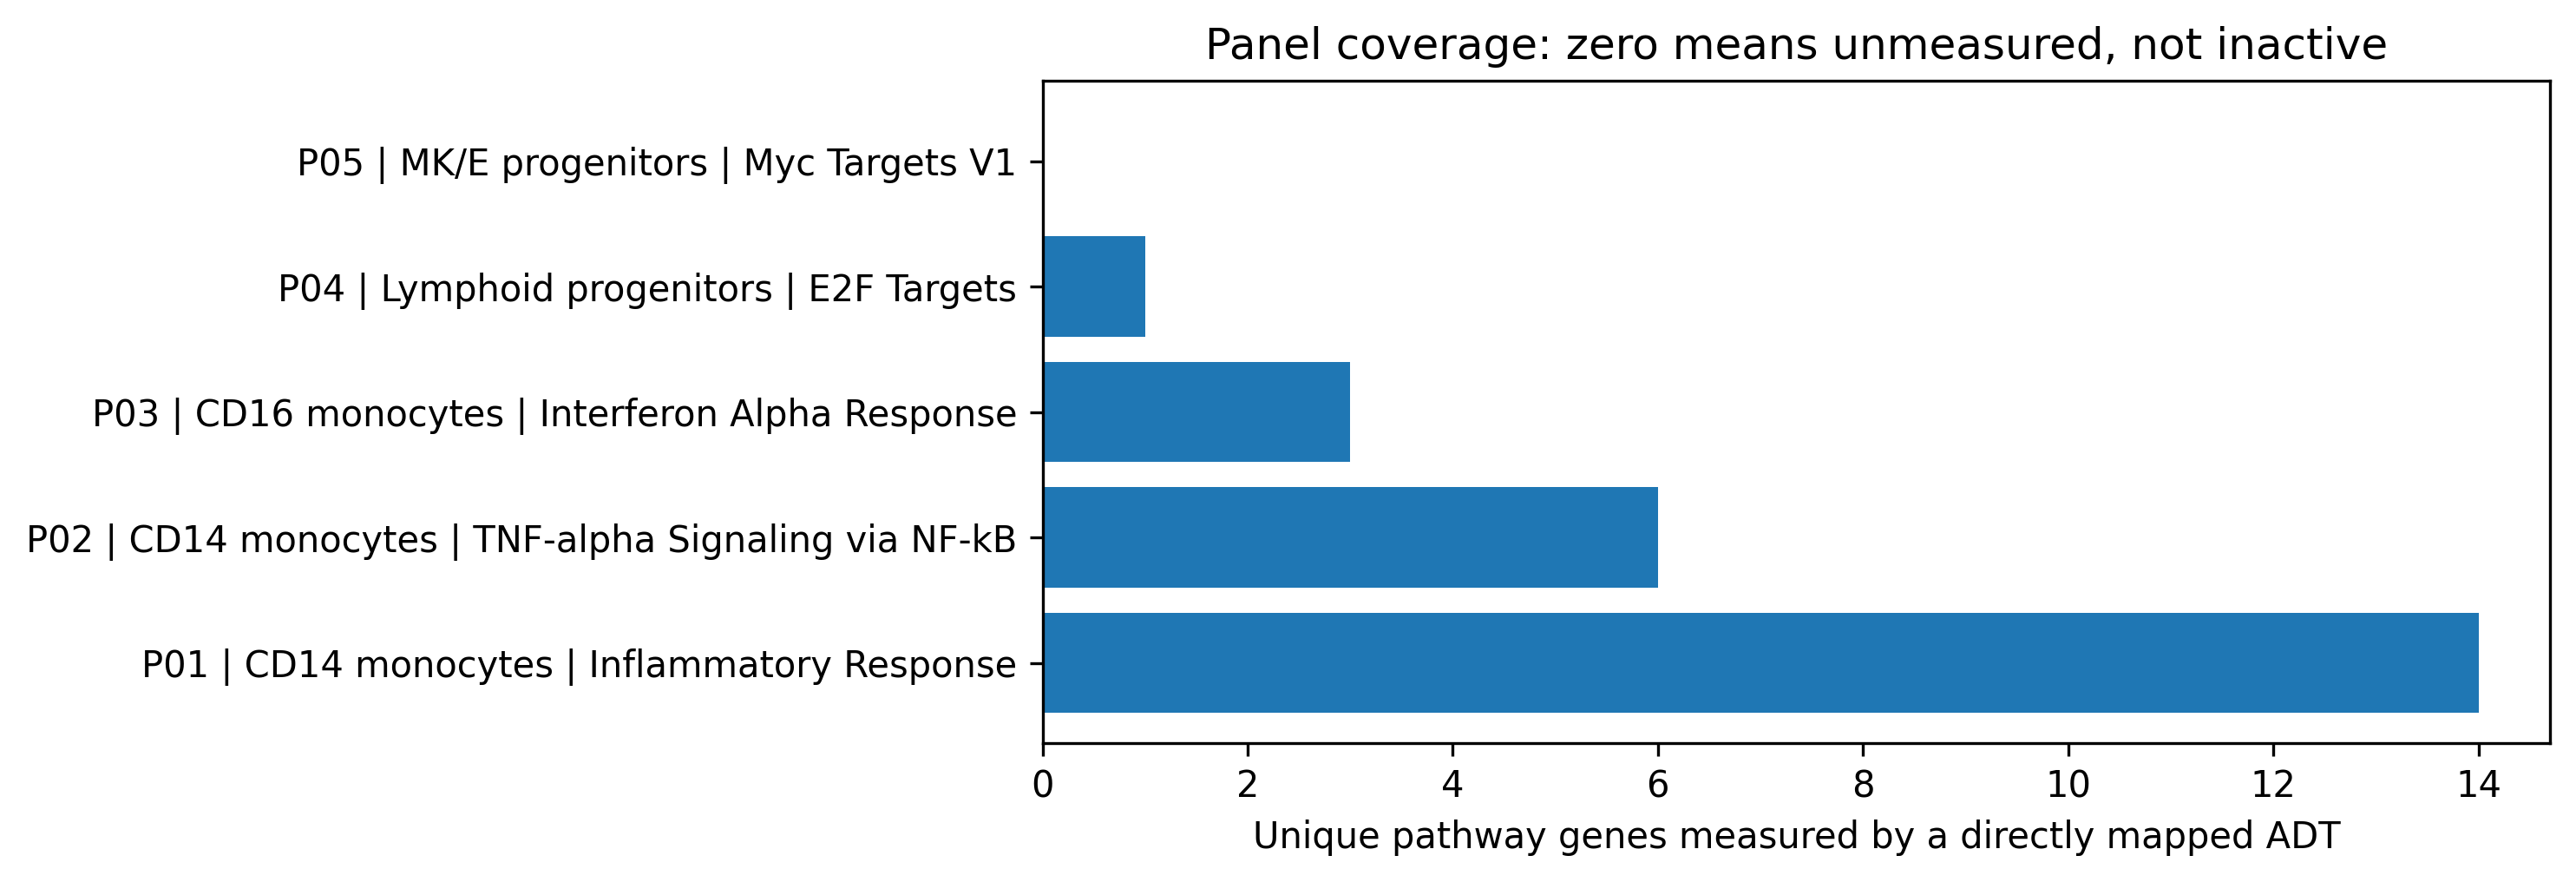





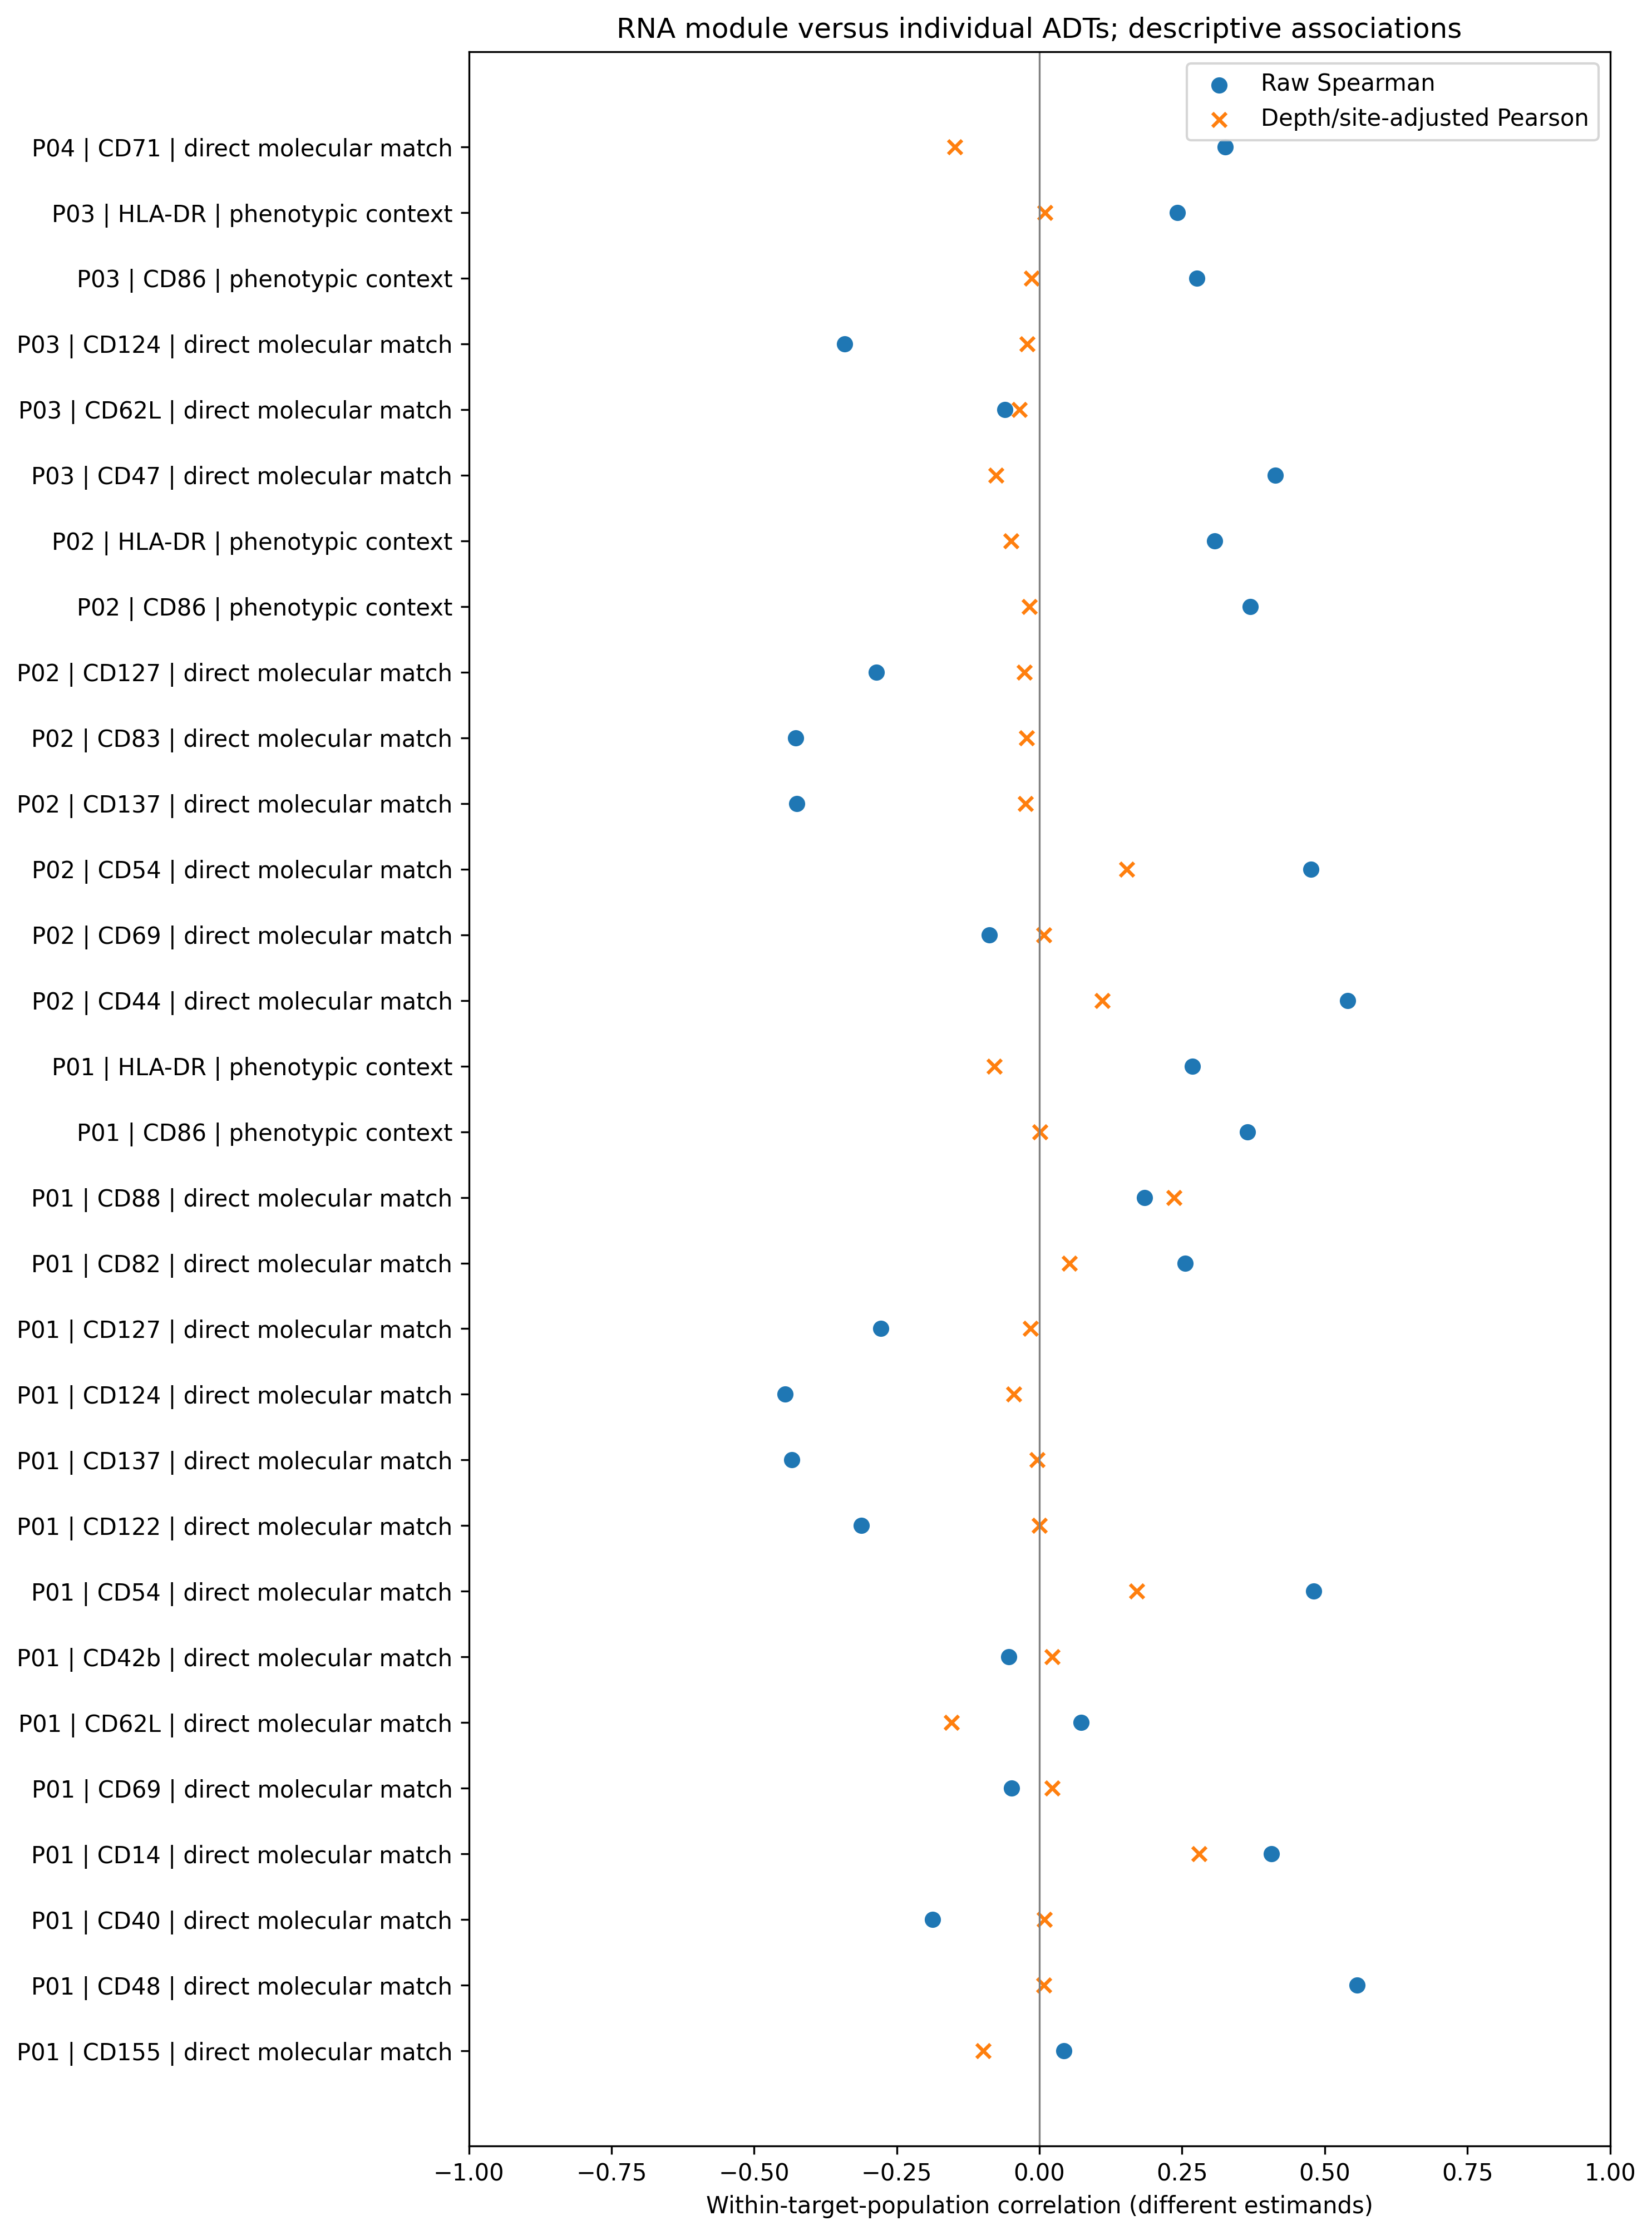

In [5]:
assoc = tables['associations']
display(assoc[assoc.scope == 'target'])
display(assoc[assoc.scope == 'target_by_site'])
display(tables['direct_gene_associations'])
for name in protein_manifest['figures']:
    display(Image(filename=str(PROTEIN_DIR / 'figures' / name)))

## Main findings
No findings are pre-filled. Review direct coverage first, then effect sizes and
sensitivity. Positive measured-subset association, phenotypic context and no direct
coverage are distinct outcomes. Lack of correlation is not evidence of absent
translation or RNA–protein decoupling without considering measurement limitations.

In [6]:
display(tables['coverage'][['program_id', 'cell_type', 'pathway', 'n_direct_genes', 'protein_coverage_status']])
print('Saved CSVs, PNG/PDF figures and provenance:', PROTEIN_DIR)
print('Elapsed minutes:', round(protein_manifest['elapsed_minutes'], 1))
print('Review these outputs before building nb08 multilayer summaries.')

,program_id,cell_type,pathway,n_direct_genes,protein_coverage_status
0,P01,CD14 monocytes,Inflammatory Response,14,measured subset only
1,P02,CD14 monocytes,TNF-alpha Signaling via NF-kB,6,measured subset only
2,P03,CD16 monocytes,Interferon Alpha Response,3,measured subset only
3,P04,Lymphoid progenitors,E2F Targets,1,measured subset only
4,P05,MK/E progenitors,Myc Targets V1,0,no direct ADT coverage


Saved CSVs, PNG/PDF figures and provenance: /content/drive/MyDrive/multiomics-relationship-modeling/results/single_donor/protein
Elapsed minutes: 0.9
Review these outputs before building nb08 multilayer summaries.


## Limitations
One donor; no independent donor replication. Limited surface panel, clone ambiguity,
no empty-droplet/background correction, and compositional ADT normalization constrain
interpretation. Adjusting library depth may remove biology as well as technical
variation. Broad cell labels may mix states. No whole-pathway protein validation,
cross-capture cell pairing, causal inference or temporal-priming claim is supported.
Site-specific cross-capture RNA pathway replication remains a separate check.

# nb07 results review — donor 15078

Reviewed 2026-10-07 using the executed notebook and copied `associations.csv`,
`direct_gene_associations.csv`, and `coverage.csv` from `results/single_donor/protein/`.
The run completed without notebook errors and retained 29,688 CITE cells.
All correlations below are descriptive; sites are subdivisions of one donor, not
independent donor replication. Pooled adjusted Pearson controls RNA/ADT library
depth and site; within-site adjusted Pearson controls the two library depths.

## Inflammatory response: consistent measured-subset support

In 7,244 CD14 monocytes, 14 of 200 pathway genes have directly mapped ADTs (7%).
The strongest positive adjusted module associations are CD14, CD88 and CD54.
All three remain positive in every site, with varying magnitudes.

| RNA measurement versus ADT | All sites | Site 1 (734 cells) | Site 2 (2,958) | Site 3 (2,915) | Site 4 (637) |
|---|---:|---:|---:|---:|---:|
| Inflammatory module–CD14 | 0.279 | 0.488 | 0.228 | 0.213 | 0.364 |
| Inflammatory module–CD88 | 0.236 | 0.392 | 0.200 | 0.153 | 0.375 |
| Inflammatory module–CD54 | 0.171 | 0.285 | 0.111 | 0.180 | 0.265 |
| CD14 RNA–CD14 ADT | 0.168 | 0.399 | 0.118 | 0.164 | 0.323 |
| C5AR1 RNA–CD88 ADT | 0.249 | 0.510 | 0.224 | 0.160 | 0.452 |
| ICAM1 RNA–CD54 ADT | 0.038 | 0.143 | 0.004 | 0.027 | 0.086 |

Values are adjusted Pearson correlations. CD14 and CD88 therefore have both
module-level association and positive same-gene agreement across sites. CD54 has
consistent module-level association but weak same-gene agreement, especially in
sites 2 and 3. These observations support a measured subset of the RNA program;
they do not validate all 200 genes or establish translation dynamics.

SELL/CD62L illustrates why the two comparisons must remain separate. Its same-gene
adjusted correlation is positive (0.194 overall; 0.149–0.309 across sites), whereas
its inflammatory-module association is negative (-0.154 overall; -0.256 to -0.099
across sites). This is not a failure of same-gene agreement. Its module association
also depends on normalization: pooled uncentered-log ADT Spearman is +0.176,
compared with centered-log Spearman +0.073 and adjusted Pearson -0.154. Different
transformations and adjustment answer different questions; no causal interpretation.

Large pooled raw effects can be misleading. Inflammatory module–CD48 Pearson drops
from 0.556 to 0.008 after adjustment; adjusted site effects range -0.079 to 0.025.
CD86 is 0.001 after adjustment, and HLA-DR is -0.079 (negative in all four sites).
These phenotypic markers do not supply consistent positive adjusted support.
The joint adjustment does not isolate how much attenuation comes from site versus
depth, and may remove biological as well as technical variation.

## TNF/NF-kB: weaker, overlapping support

Six of 200 genes have directly mapped ADTs (3%). Module–CD54 is positive in every
site (overall 0.153; sites 0.080–0.275), as is module–CD44 (overall 0.110; sites
0.064–0.203). Same-gene CD44 agreement is weak (0.084 overall; sites 0.047–0.116),
and ICAM1/CD54 agreement is the same weak result above. CD86/HLA-DR provide no
consistent positive adjusted support. The two CD14 programs overlap and share
cells and markers; they are not independent confirmations.

## Interferon-alpha, E2F and Myc

- **CD16 interferon-alpha:** three of 97 genes measured (3.1%), 865 cells. Direct
  module associations are weak overall: CD47 -0.077, CD62L -0.035, CD124 -0.021.
  CD47 is negative in all three testable sites (-0.119, -0.006, -0.286), despite
  positive pooled raw Pearson (0.387). Same-gene CD47 agreement is weakly positive
  (0.065 overall). Site 1 has 45 cells, below the 50-cell threshold: its missing
  correlations are **untested**, never zero. CD86 and HLA-DR context is inconsistent.
  No consistent positive adjusted protein support is established by this panel.
- **Lymphoid progenitor E2F:** only TFRC/CD71 is measured (1/200; 0.5%), 449 cells.
  Module–CD71 changes from raw Pearson 0.308 to adjusted -0.148. Adjusted site
  effects are +0.148, -0.205, -0.001 and -0.229. TFRC RNA–CD71 ADT is weakly
  positive overall (0.095), but site effects also vary (-0.096 to 0.207). This is
  insufficient evidence for pathway-wide protein support or biological decoupling.
- **MK/E Myc:** zero of 200 genes have direct ADT coverage. Protein support is
  unmeasured; no negative biological conclusion is justified.

## Implications for nb08

Prioritize the CD14 inflammatory program as the clearest measured-subset protein
result, retaining CD14 and C5AR1/CD88 as the strongest same-gene examples. Include
CD54 as module-level support with weak same-gene agreement. Retain TNF/NF-kB as
weaker overlapping evidence; label interferon/E2F as lacking consistent positive
adjusted support and Myc as unmeasured.

These results can accompany the previously reviewed RNA and ATAC findings in a
descriptive multilayer summary. They do not resolve site-specific **cross-capture
RNA pathway** replication or the seven unavailable nb05 enrichment scores, which
remain separate checks. RNA module scores include the matched gene: a future
leave-one-gene-out sensitivity analysis would separate broader-program association
from that gene's own contribution. Limited antibody coverage, relative ADT
normalization, no background correction and single-donor sampling remain limitations.


### Reviewed input SHA256 fingerprints

- `associations.csv`: `e26e0799efab5bb737bffd95987612939e179667bdfb6c693103e2980a0feed5`
- `direct_gene_associations.csv`: `d803b57bf62c901005441c9367ba5a5b4df7b22e3dcc56f614890c89fd5879b9`
- `coverage.csv`: `d7698de9386f2985f3f6ff4b6dc595e61052baf5a678db08b8e32b44ec82f596`


## Follow-up validation status

The detailed reviewed analysis above remains applicable. The next protein-specific check is a leave-one-gene-out module sensitivity analysis for CD14, C5AR1/CD88 and ICAM1/CD54. It is planned, not yet executed. Shared-site cross-capture RNA pathway checks and the unavailable nb05 NES audit are also pending. These checks should precede donor-generalization claims.


## Validation update — supersedes earlier pending-check notes

The three planned checks have now been executed locally. The report below records the results and remaining limits; earlier executed outputs are preserved.

# Completed single-donor validation — donor 15078

Executed locally on 2026-10-07 with `scripts/validate_single_donor.py`. All
manifest-listed input SHA256 fingerprints matched. The copied CITE source matched
the expected size and cell metadata; its SHA256 is recorded in the validation
manifest. Upstream results were not replaced.

## Shared-site RNA pathway consistency

Recomputed cell-type specificity independently in each capture within sites 1, 2
and 4. Within each site, both captures used exactly the same reference cell types,
each with at least 50 cells in both captures, and the frozen 12,000-gene universe.
Reference types can differ between sites. Used 1,000 gene-set permutations and BH
adjustment across all eligible Hallmark sets per target/capture/site, then inspected
the five preselected programs. No cells were paired across captures.

| Program | Testable shared sites | Positive NES and q <= 0.05 in both captures |
|---|---|---|
| CD14 inflammatory response | 1, 2, 4 | 3/3 |
| CD14 TNF/NF-kB | 1, 2, 4 | 3/3 |
| CD16 interferon-alpha | 2, 4 | 2/2 |
| Lymphoid progenitor E2F | 1, 2, 4 | 3/3 |
| MK/E progenitor Myc V1 | None | Untested |

All 11 testable comparisons agreed positively (maximum q approximately 0.021).
CD16 site 1 has only 45 CITE cells. MK/E CITE counts are 14, 43 and 31 in sites
1, 2 and 4; Multiome site 2 also has only 33. These are insufficient groups, not
failed replication. CITE site 3 has no corresponding Multiome site for this donor.
Thus pooled Myc RNA agreement remains without a sufficiently powered site check
under the specified cell-count rule. Site-level agreement is within-donor
consistency, not independent biological replication. No balanced-cell resampling
or donor-level significance is implied by this check.

## Seven unavailable nb05 NES values

All seven had finite negative observed enrichment scores but **zero negative
same-sign null draws among the original 1,000 permutations**. The implemented
same-sign normalization and conditional p-value are consequently undefined.
This is not missing gene coverage or evidence of zero enrichment.

One affected CITE cDC2 heme metabolism. Six affected Multiome G/M progenitors:
allograft rejection, complement, inflammatory response, interferon-gamma response,
TNF/NF-kB and heme metabolism. None is one of our five selected cell-type/pathway
pairs, so this numerical issue does not invalidate their recorded enrichment scores.

An independent 10,000-draw diagnostic yielded only 0–14 same-sign draws per affected
test; G/M interferon-gamma still had zero. Exploratory finite NES estimates based
on 1–14 draws are unstable and must not replace the original missing values or be
used for new significance claims. The cause is established, but reliable normalized
scores for these seven tests remain unavailable. A future change to the null model
or enrichment method must be evaluated systematically, not used selectively to
recover preferred results.

## Leave-one-gene-out protein sensitivity

Reproduced the original nb07 full-module adjusted correlations to tolerance 1e-8
for all three antigens, overall and in each site. Removed only the matched RNA gene
from the 128-gene inflammatory module, leaving 127 genes with the same per-gene
reference standardization. ADT transformation, cells and adjustment stayed fixed.

| ADT | Removed RNA gene | Full adjusted Pearson | Leave-one-out adjusted Pearson | Leave-one-out site range |
|---|---|---:|---:|---:|
| CD14 | CD14 | 0.279 | 0.268 | 0.198–0.475 |
| CD88 | C5AR1 | 0.236 | 0.217 | 0.139–0.364 |
| CD54 | ICAM1 | 0.171 | 0.169 | 0.112–0.278 |

Every association remains positive in all four CITE sites. Inclusion of the matched
gene alone does not explain these module–protein relationships. Other correlated
genes remain in the score, so this does not establish independent mechanistic or
causal evidence. ICAM1/CD54 same-gene agreement remains weak despite its broader
module association.

## Updated interpretation and next step

The CD14 inflammatory program retains the clearest measured-subset support across
RNA, ATAC and protein. TNF/NF-kB has strong RNA–ATAC and weaker protein support.
Interferon and E2F RNA enrichment now show within-site cross-capture consistency,
but this does not strengthen their weak downstream associations automatically.
Myc protein coverage and within-site RNA validation remain unavailable.

The three requested checks have been executed; their coverage and numerical limits
remain explicit. The next substantive step is testing the leading programs across
additional donors with donor-aware summaries, before full latent integration.

Detailed tables and reproducibility metadata are in
`results/single_donor/validation/`: `site_coverage.csv`,
`site_enrichment_all_sets.csv`, `site_pathway_comparison.csv`,
`missing_nes_audit.csv`, `protein_leave_one_gene_out.csv`, and `manifest.json`.
